<a href="https://colab.research.google.com/github/Kaashish1111/Linear_regression/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

pd.read_csv("file2.csv", on_bad_lines="skip").head()

,2K20/MC/014,adityasinghchauhan_mc20a9_81@dtu.a\nc.in,8.92,Fast Retailing,37,27
0,2K20/MC/015,aftabaziz_mc20a6_52@dtu.ac.in,7.78,PlanetSpark,7.00,4.90
1,2K20/MC/016,akashbharangar_mc20b14_68@dtu.ac.i\nn,7.89,NaN,NaN,NaN
2,2K20/MC/017,akshaypandey_mc20a6_54@dtu.ac.in,9.31,AMD,13.17,12.15
3,2K20/MC/018,amaanakhter_mc20b11_67@dtu.ac.in,7.63,TCS,3.30,3.30
4,NaN,amankumar_mc20a6_55@dtu.ac.in,8.29,TalentServe\n6Mo HR\nMGMT,5.50,4.00


In [4]:
import pandas as pd

cols = ["Roll", "Email", "CGPA", "Company", "CTC", "Base"]

df2 = pd.read_csv(
    "file2.csv",
    header=None,
    names=cols,
    engine="python",
    on_bad_lines="skip"
)

df2.head()

,Roll,Email,CGPA,Company,CTC,Base
0,2K20/MC/014,adityasinghchauhan_mc20a9_81@dtu.a\nc.in,8.92,Fast Retailing,37.00,27.00
1,2K20/MC/015,aftabaziz_mc20a6_52@dtu.ac.in,7.78,PlanetSpark,7.00,4.90
2,2K20/MC/016,akashbharangar_mc20b14_68@dtu.ac.i\nn,7.89,NaN,NaN,NaN
3,2K20/MC/017,akshaypandey_mc20a6_54@dtu.ac.in,9.31,AMD,13.17,12.15
4,2K20/MC/018,amaanakhter_mc20b11_67@dtu.ac.in,7.63,TCS,3.30,3.30


In [5]:
import pandas as pd

cols = ["Roll", "Email", "CGPA", "Company", "CTC", "Base"]

dfs = []

for i in range(1, 6):
    df = pd.read_csv(
        f"file{i}.csv",
        header=None,
        names=cols,
        engine="python",
        on_bad_lines="skip"
    )
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print(df.shape)
df.head()

(149, 6)


,Roll,Email,CGPA,Company,CTC,Base
0,Roll Number,DTU ID,CGP\nA,Company\nName,CTC\n(in\nlakhs\n),Base\n(in\nlakhs\n)
1,2K20/MC/001,aakashyadav_mc20b15_69@dtu.ac.in,7.82,TalentServe Tech 6Mo,6,3.5
2,2K20/MC/002,abhaychauhan_mc20a6_39@dtu.ac.in,8.34,NaN,NaN,NaN
3,2K20/MC/003,abhinavanand_mc20a6_40@dtu.ac.in,7.87,NaN,NaN,NaN
4,2K20/MC/004,abhinavsinha_mc20a6_41@dtu.ac.in,9.34,Wells Fargo,24,16


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Roll     147 non-null    object
 1   Email    149 non-null    object
 2   CGPA     149 non-null    object
 3   Company  109 non-null    object
 4   CTC      108 non-null    object
 5   Base     101 non-null    object
dtypes: object(6)
memory usage: 7.1+ KB


In [11]:
df = df.iloc[1:].reset_index(drop=True)

In [12]:
df["CGPA"] = pd.to_numeric(df["CGPA"], errors="coerce")
df["CTC"] = pd.to_numeric(df["CTC"], errors="coerce")
df["Base"] = pd.to_numeric(df["Base"], errors="coerce")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Roll     146 non-null    object 
 1   Email    148 non-null    object 
 2   CGPA     148 non-null    float64
 3   Company  108 non-null    object 
 4   CTC      107 non-null    float64
 5   Base     100 non-null    float64
dtypes: float64(3), object(3)
memory usage: 7.1+ KB


In [14]:
df.describe()

,CGPA,CTC,Base
count,148.000000,107.000000,100.000000
mean,8.435541,16.337477,10.811100
std,0.639520,11.843458,5.670355
min,6.440000,3.300000,3.000000
25%,8.007500,7.970000,6.937500
50%,8.460000,11.890000,9.500000
75%,8.952500,21.640000,15.000000
max,9.790000,51.030000,30.000000


In [15]:
df.isnull().sum()

,0
Roll,2
Email,0
CGPA,0
Company,40
CTC,41
Base,48


In [16]:
df_lr = df[["CGPA", "CTC"]]

In [17]:
df_lr = df_lr.dropna()

In [18]:
df_lr.isnull().sum()

,0
CGPA,0
CTC,0


In [19]:
df_lr.head()

,CGPA,CTC
0,7.82,6.0
3,9.34,24.0
4,8.48,6.0
5,9.19,24.0
6,8.59,5.5


In [20]:
df_lr.describe()

,CGPA,CTC
count,107.000000,107.000000
mean,8.555047,16.337477
std,0.575295,11.843458
min,6.750000,3.300000
25%,8.205000,7.970000
50%,8.530000,11.890000
75%,9.025000,21.640000
max,9.790000,51.030000


In [21]:
X = df_lr[["CGPA"]]
y = df_lr["CTC"]

In [22]:
X.head()

,CGPA
0,7.82
3,9.34
4,8.48
5,9.19
6,8.59


In [23]:
y.head()

,CTC
0,6.0
3,24.0
4,6.0
5,24.0
6,5.5


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model = LinearRegression()

In [28]:
model.fit(X_train, y_train)

LinearRegression()

In [29]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [7.14281111]
Intercept: -45.23846410904595


In [31]:
y_pred = model.predict(X_test)
print(y_pred)

[19.47540453 18.47541098 16.11828331 13.33258698 21.54681975 21.26110731
 14.1182962  21.76110409 17.26113309 10.33260631 19.2611202  23.90394742
 10.61831876 10.61831876 11.76116853 14.40400864 12.61830587 14.54686487
 16.26113953 15.90399898 21.26110731 14.7611492 ]


In [32]:
comparison = X_test.copy()

comparison["Actual CTC"] = y_test.values
comparison["Predicted CTC"] = y_pred

comparison.head(10)

,CGPA,Actual CTC,Predicted CTC
104,9.06,51.03,19.475405
13,8.92,37.00,18.475411
6,8.59,5.50,16.118283
138,8.20,22.02,13.332587
94,9.35,15.00,21.546820
86,9.31,51.03,21.261107
43,8.31,20.00,14.118296
62,9.38,32.75,21.761104
131,8.75,8.40,17.261133
14,7.78,7.00,10.332606


In [33]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print(score)

0.24836894374740226


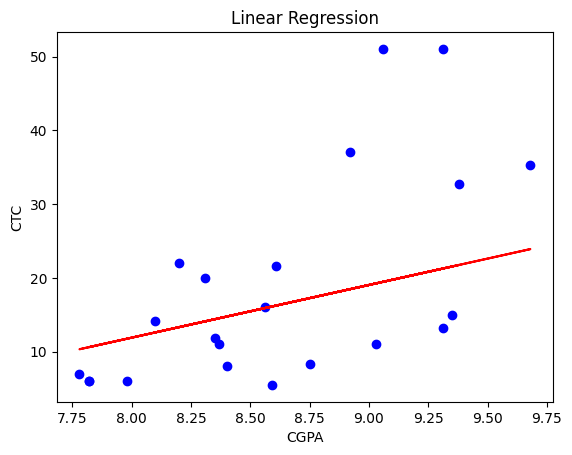

In [34]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color="blue")
plt.plot(X_test, y_pred, color="red")

plt.xlabel("CGPA")
plt.ylabel("CTC")
plt.title("Linear Regression")

plt.show()

In [35]:
print(model.coef_)
print(model.intercept_)

[7.14281111]
-45.23846410904595


In [36]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.24836894374740226
MAE: 8.964981675126754
MSE: 142.49606506053462


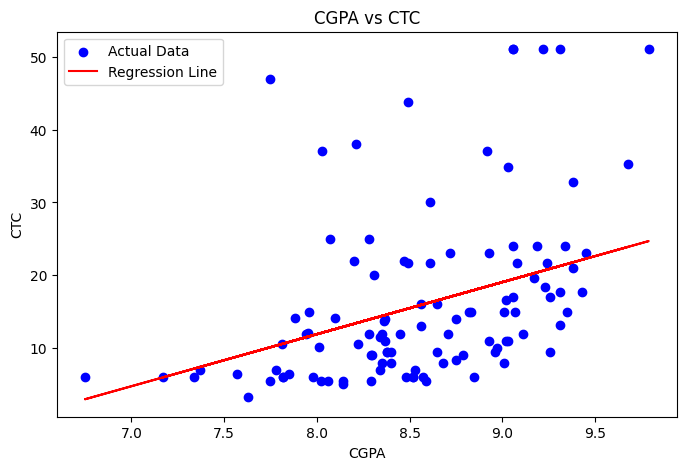

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, model.predict(X), color="red", label="Regression Line")

plt.xlabel("CGPA")
plt.ylabel("CTC")
plt.title("CGPA vs CTC")
plt.legend()

plt.show()

In [44]:
import pandas as pd

cgpa = float(input("Enter your CGPA: "))

new_data = pd.DataFrame({"CGPA": [cgpa]})

prediction = model.predict(new_data)

print(f"Predicted CTC: {prediction[0]:.2f} LPA")

Enter your CGPA: 10
Predicted CTC: 26.19 LPA
